In [ ]:
import tensorflow as tf 
from tensorflow.keras import datasets,layers,models 
import matplotlib.pyplot as plt 

In [ ]:
(train_images , train_labels) , (test_images , test_labels) = datasets.cifar10.load_data() 
train_images , test_images = train_images/255.0 , test_images/255.0 
class_names = [ 'dog' ]

170508288/170498071 [==============================] - 11s 0us/step


In [ ]:
model = models.Sequential() 
model.add(layers.Conv2D(32 , (3,3) , activation = 'relu' )) 
model.add(layers.MaxPooling2D((2,2))) 
model.add(layers.Conv2D(64 , (3,3) , activation = 'relu')) 
model.add(layers.MaxPooling2D(2,2)) 
model.add(layers.Conv2D(64 , (3,3) , activation = 'relu')) 

In [ ]:
model.add(layers.Flatten()) 
model.add(layers.Dense(64 , activation ='relu')) 
model.add(layers.Dense(10)) 

In [ ]:
model.compile(
           optimizer = 'adam' ,
           loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
           metrics = ['accuracy'] ) 
history = model.fit(train_images , train_labels , epochs =10 ,
                    validation_data = (test_images , test_labels)) 

Epoch 1/10
1563/1563 [==============================] - 69s 43ms/step - loss: 1.5336 - accuracy: 0.4386 - val_loss: 1.2332 - val_accuracy: 0.5602
Epoch 2/10
1563/1563 [==============================] - 67s 43ms/step - loss: 1.1678 - accuracy: 0.5886 - val_loss: 1.0676 - val_accuracy: 0.6269
Epoch 3/10
1563/1563 [==============================] - 74s 47ms/step - loss: 1.0229 - accuracy: 0.6417 - val_loss: 0.9982 - val_accuracy: 0.6506
Epoch 4/10
1563/1563 [==============================] - 67s 43ms/step - loss: 0.9312 - accuracy: 0.6751 - val_loss: 0.9320 - val_accuracy: 0.6777
Epoch 5/10
1563/1563 [==============================] - 66s 42ms/step - loss: 0.8585 - accuracy: 0.7009 - val_loss: 0.8992 - val_accuracy: 0.6909
Epoch 6/10
1563/1563 [==============================] - 64s 41ms/step - loss: 0.7998 - accuracy: 0.7185 - val_loss: 1.0046 - val_accuracy: 0.6537
Epoch 7/10
1563/1563 [==============================] - 64s 41ms/step - loss: 0.7458 - accuracy: 0.7368 - val_loss: 0.8782 -

In [ ]:
test_loss , test_acc = model.evaluate(test_images , test_labels , verbose =2) 
print(test_acc) 

313/313 - 3s - loss: 0.8723 - accuracy: 0.7120 - 3s/epoch - 11ms/step
0.7120000123977661


Data Augmentation

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


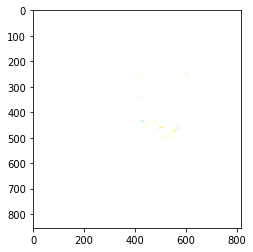

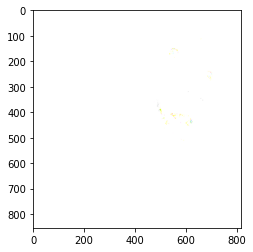

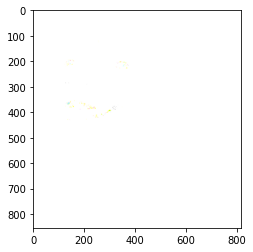

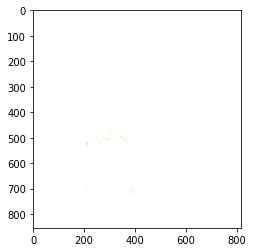

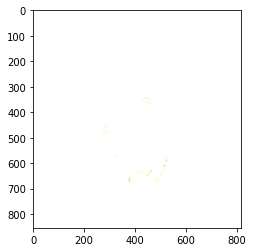

In [ ]:
from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator 
from keras.preprocessing.image import load_img
import matplotlib.pyplot as plt

datagen = ImageDataGenerator(
          rotation_range =40 ,
          width_shift_range = 0.2 ,
          height_shift_range= 0.2 ,
          shear_range =0.2 ,
          zoom_range = 0.2 ,
          horizontal_flip = True ,
          vertical_flip = True , 
)
test_image = load_img('dog.jpg') 
img = image.img_to_array(test_image) 
img = img.reshape((1,) + img.shape) 
i=0 
for batch in datagen.flow( img , save_prefix = 'test' , save_format = 'jpg'): 
  plt.figure(i) 
  plot =plt.imshow(image.img_to_array(batch[0])) 
  i += 1
  if i > 4: 
      break 
plt.show()